In [47]:
import pandas as pd
import numpy as np


In [48]:
predicted = pd.read_csv('tkcm/chlorine_predictions.csv')
predicted.columns = ['actual', 'predicted']
predicted.head()

,actual,predicted
0,0.957788,0.944907
1,0.958251,0.938046
2,0.958832,0.929828
3,0.959530,0.920160
4,0.960349,0.909082


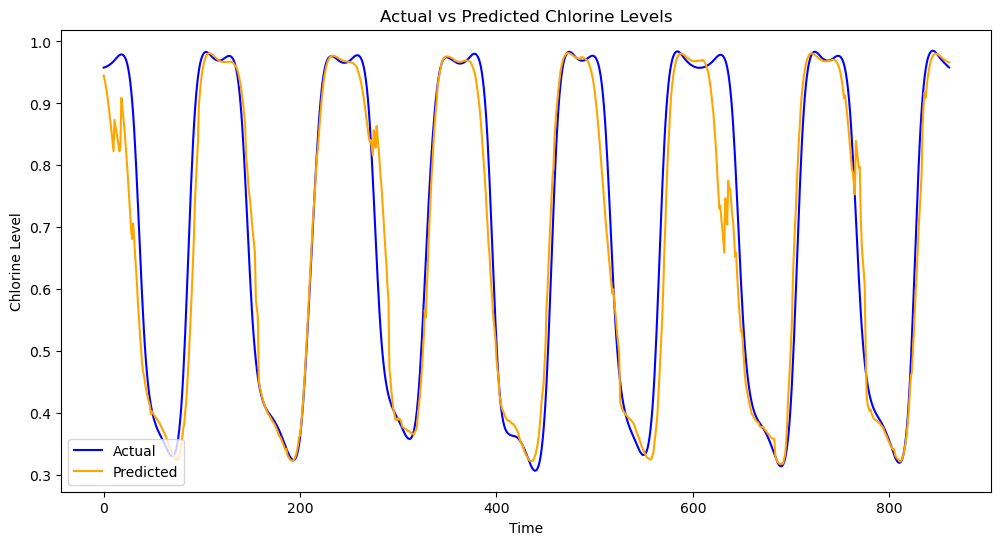

In [49]:
# plot the time series of actual and predicted values
import matplotlib.pyplot as plt



plt.figure(figsize=(12, 6))
plt.plot(predicted['actual'], label='Actual', color='blue')
plt.plot(predicted['predicted'], label='Predicted', color='orange')
plt.title('Actual vs Predicted Chlorine Levels')
plt.xlabel('Time')
plt.ylabel('Chlorine Level')
# position the legend outside the plot
plt.legend(loc='lower left')
plt.savefig('figures/chlorine_predictions.png')
plt.show()


(4310, 166)


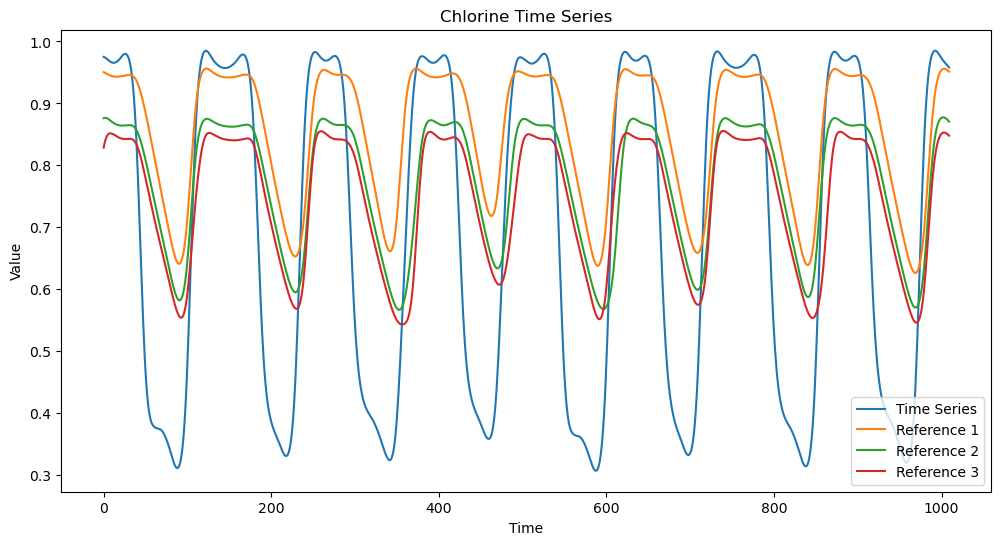

In [50]:


# load file
data = np.loadtxt("tkcm/cl2fullLarge.dat")

# extract columns
ts = data[:, 0]
ref1 = data[:, 1]
ref2 = data[:, 2]
ref3 = data[:, 3]

print(data.shape)
plt.figure(figsize=(12, 6))
plt.plot(ts[3300:], label='Time Series')
plt.plot(ref1[3300:], label='Reference 1')
plt.plot(ref2[3300:], label='Reference 2')
plt.plot(ref3[3300:], label='Reference 3')
plt.title('Chlorine Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.savefig('figures/chlorine_time_series.png')
plt.show()

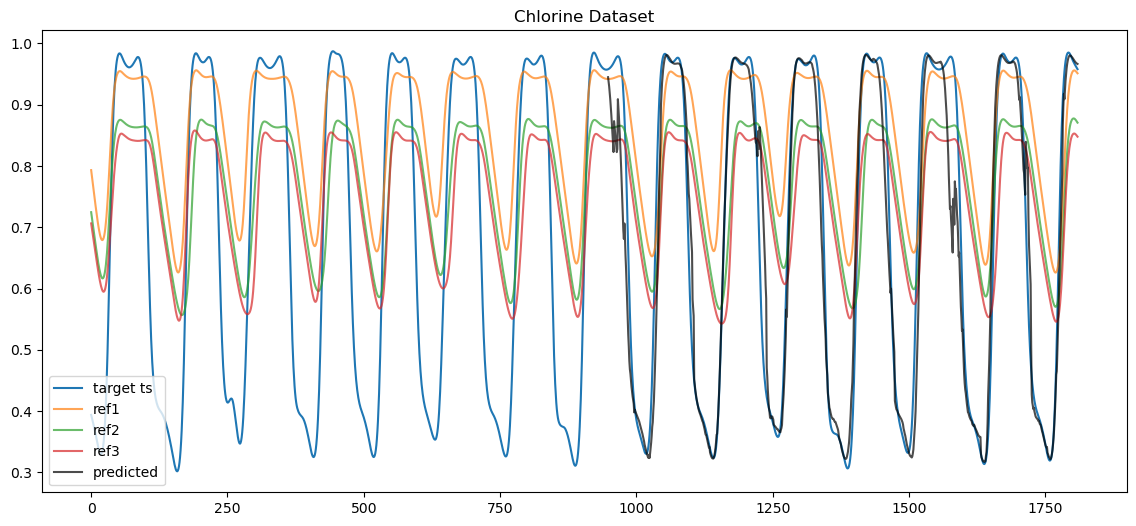

In [51]:

# plot the time series of target and reference signals
# plot the predicted values aswell such that we can compare them to the target and reference signals

# need to pad the predicted values with NaN values to match the length of the target and reference signals
predicted_padded = np.full_like(ts, np.nan)
predicted_padded[len(predicted_padded)-len(predicted):] = predicted['predicted']
start = 2500
plt.figure(figsize=(14,6))

plt.plot(ts[start:], label="target ts")
plt.plot(ref1[start:], label="ref1", alpha=0.7)
plt.plot(ref2[start:], label="ref2", alpha=0.7)
plt.plot(ref3[start:], label="ref3", alpha=0.7)
plt.plot(predicted_padded[start:], label='predicted', color='black', alpha=0.7)

plt.legend(loc='lower left')
plt.title("Chlorine Dataset")
plt.savefig('figures/chlorine_dataset.png')
plt.show()


In [52]:
# comput the mean squared error between the predicted and actual values
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(predicted['actual'], predicted['predicted'])
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 0.00570621337887007


In [53]:
df = pd.read_csv("tkcm/results.csv")

print(df.head())

   mode  k   l  d  alpha  index      real      pred     error
0  mean  3  12  3    0.5   3447  0.957443  0.962760  0.005316
1  mean  3  12  3    0.5   3448  0.957788  0.964303  0.006515
2  mean  3  12  3    0.5   3449  0.958251  0.963311  0.005059
3  mean  3  12  3    0.5   3450  0.958832  0.964303  0.005472
4  mean  3  12  3    0.5   3451  0.959530  0.965330  0.005800


In [54]:
df.groupby("mode")["error"].mean()

mode
mean            0.039796
weighted_exp    0.039691
weighted_inv    0.037970
Name: error, dtype: float64

In [55]:
df.groupby("mode")["error"].describe()

,count,mean,std,min,25%,50%,75%,max
mode,,,,,,,,
mean,17260.0,0.039796,0.057176,0.000000,0.004220,0.013631,0.051677,0.429003
weighted_exp,17260.0,0.039691,0.057039,0.000000,0.004213,0.013569,0.051380,0.429415
weighted_inv,17260.0,0.037970,0.056190,0.000004,0.004005,0.012398,0.047997,0.435577


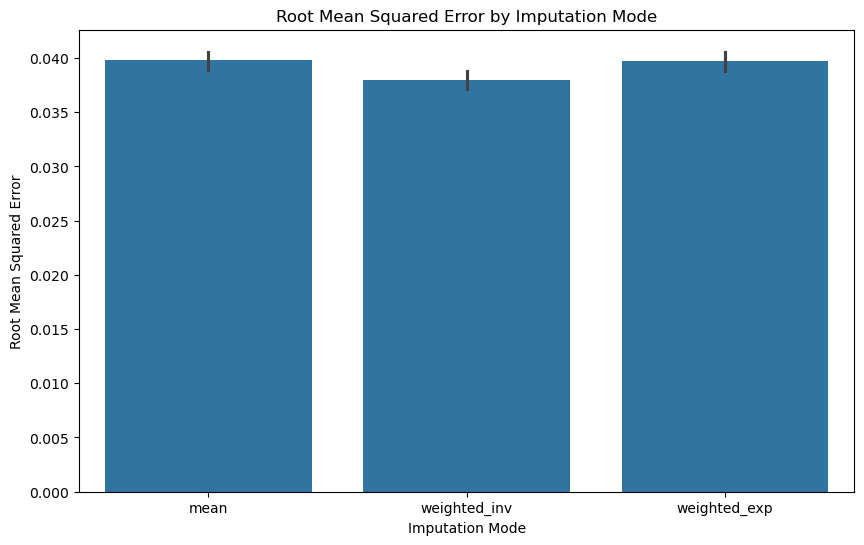

In [56]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="mode", y="error", data=df)
plt.title("Root Mean Squared Error by Imputation Mode")
plt.ylabel("Root Mean Squared Error")
plt.xlabel("Imputation Mode")
plt.savefig('figures/imputation_mode_rmse.png')
plt.show()


In [57]:
# rank the grouped results by error
grouped_df = df.groupby(["mode", "k", "l"])["error"].mean().reset_index()
sorted_df = grouped_df.sort_values("error")
sorted_df.head()

,mode,k,l,error
40,weighted_inv,3,12,0.024831
41,weighted_inv,3,24,0.026583
45,weighted_inv,5,12,0.027851
46,weighted_inv,5,24,0.028439
20,weighted_exp,3,12,0.028729


In [71]:
# best parameter combination per mode
best_params = grouped_df.loc[
    grouped_df.groupby("mode")["error"].idxmin()
]
print("Original chlorine dataset results:")
print("Best parameter combinations per mode:")
print(best_params)
worst_params = grouped_df.loc[
    grouped_df.groupby("mode")["error"].idxmax()
]
print("Worst parameter combinations per mode:")
print(worst_params)

Original chlorine dataset results:
Best parameter combinations per mode:
            mode  k   l     error
0           mean  3  12  0.028801
20  weighted_exp  3  12  0.028729
40  weighted_inv  3  12  0.024831
Worst parameter combinations per mode:
            mode  k   l     error
19          mean  9  96  0.051667
39  weighted_exp  9  96  0.051430
54  weighted_inv  7  96  0.050794


In [60]:
best_params_dict = {}

for mode in best_params["mode"].unique():
    row = best_params[best_params["mode"] == mode].iloc[0]
    k = row["k"]
    l = row["l"]
    mode = row["mode"]
    print(f"Best parameters for mode {mode}: k={row['k']}, l={row['l']} with error={row['error']}")
    # store the best parameters for each mode in a dictionary
    best_params_dict[mode] = {"k": k, "l": l}

worst_params_dict = {}
for mode in worst_params["mode"].unique():
    row = worst_params[worst_params["mode"] == mode].iloc[0]
    k = row["k"]
    l = row["l"]
    mode = row["mode"]
    print(f"Worst parameters for mode {mode}: k={row['k']}, l={row['l']} with error={row['error']}")
    # store the worst parameters for each mode in a dictionary
    
    worst_params_dict[mode] = {"k": k, "l": l}

Best parameters for mode mean: k=3, l=12 with error=0.02880128852838934
Best parameters for mode weighted_exp: k=3, l=12 with error=0.028729368482039396
Best parameters for mode weighted_inv: k=3, l=12 with error=0.02483143453070684
Worst parameters for mode mean: k=9, l=96 with error=0.05166721784472769
Worst parameters for mode weighted_exp: k=9, l=96 with error=0.05142986326767091
Worst parameters for mode weighted_inv: k=7, l=96 with error=0.05079351100811124


In [61]:
best_params_dict

{'mean': {'k': np.int64(3), 'l': np.int64(12)},
 'weighted_exp': {'k': np.int64(3), 'l': np.int64(12)},
 'weighted_inv': {'k': np.int64(3), 'l': np.int64(12)}}

In [62]:
worst_params_dict

{'mean': {'k': np.int64(9), 'l': np.int64(96)},
 'weighted_exp': {'k': np.int64(9), 'l': np.int64(96)},
 'weighted_inv': {'k': np.int64(7), 'l': np.int64(96)}}

In [63]:
best_runs = df.merge(best_params, on=["mode", "k", "l"], how="inner")
worst_runs = df.merge(worst_params, on=["mode", "k", "l"], how="inner")
best_runs.head()

,mode,k,l,d,alpha,index,real,pred,error_x,error_y
0,mean,3,12,3,0.5,3447,0.957443,0.962760,0.005316,0.028801
1,mean,3,12,3,0.5,3448,0.957788,0.964303,0.006515,0.028801
2,mean,3,12,3,0.5,3449,0.958251,0.963311,0.005059,0.028801
3,mean,3,12,3,0.5,3450,0.958832,0.964303,0.005472,0.028801
4,mean,3,12,3,0.5,3451,0.959530,0.965330,0.005800,0.028801


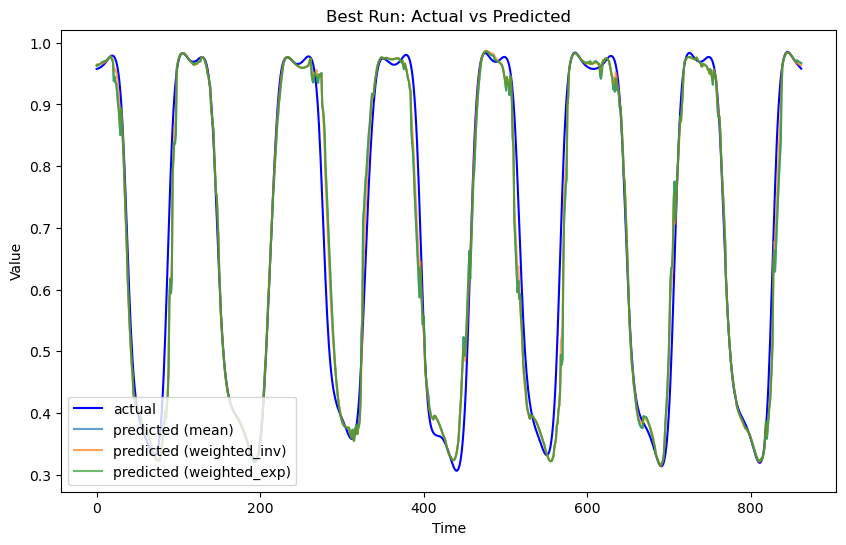

In [64]:
real_ts = best_runs[best_runs["mode"] == "mean"]["real"].to_numpy()
plt.figure(figsize=(10,6))
plt.plot(real_ts, label="actual", color="blue")
for mode in best_runs["mode"].unique():
    predicted_ts = best_runs[best_runs["mode"] == mode]["pred"].to_numpy()
    plt.plot(predicted_ts, label=f"predicted ({mode})", alpha=0.7)

plt.title("Best Run: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower left')
plt.savefig('figures/best_run_predictions.png')
plt.show()


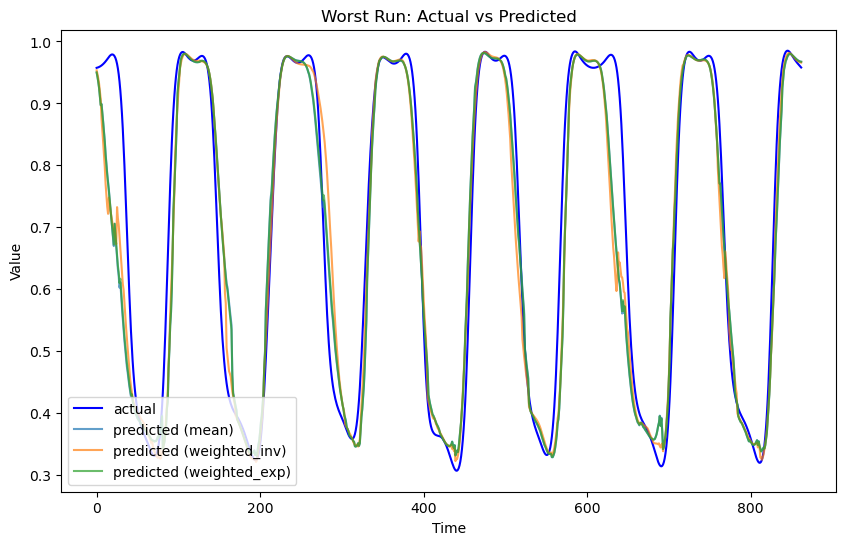

In [65]:
plt.figure(figsize=(10,6))
plt.plot(real_ts, label="actual", color="blue")
for mode in worst_runs["mode"].unique():
    predicted_ts = worst_runs[worst_runs["mode"] == mode]["pred"].to_numpy()
    plt.plot(predicted_ts, label=f"predicted ({mode})", alpha=0.7)

plt.title("Worst Run: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(loc='lower left')
plt.savefig('figures/worst_run_predictions.png')
plt.show()


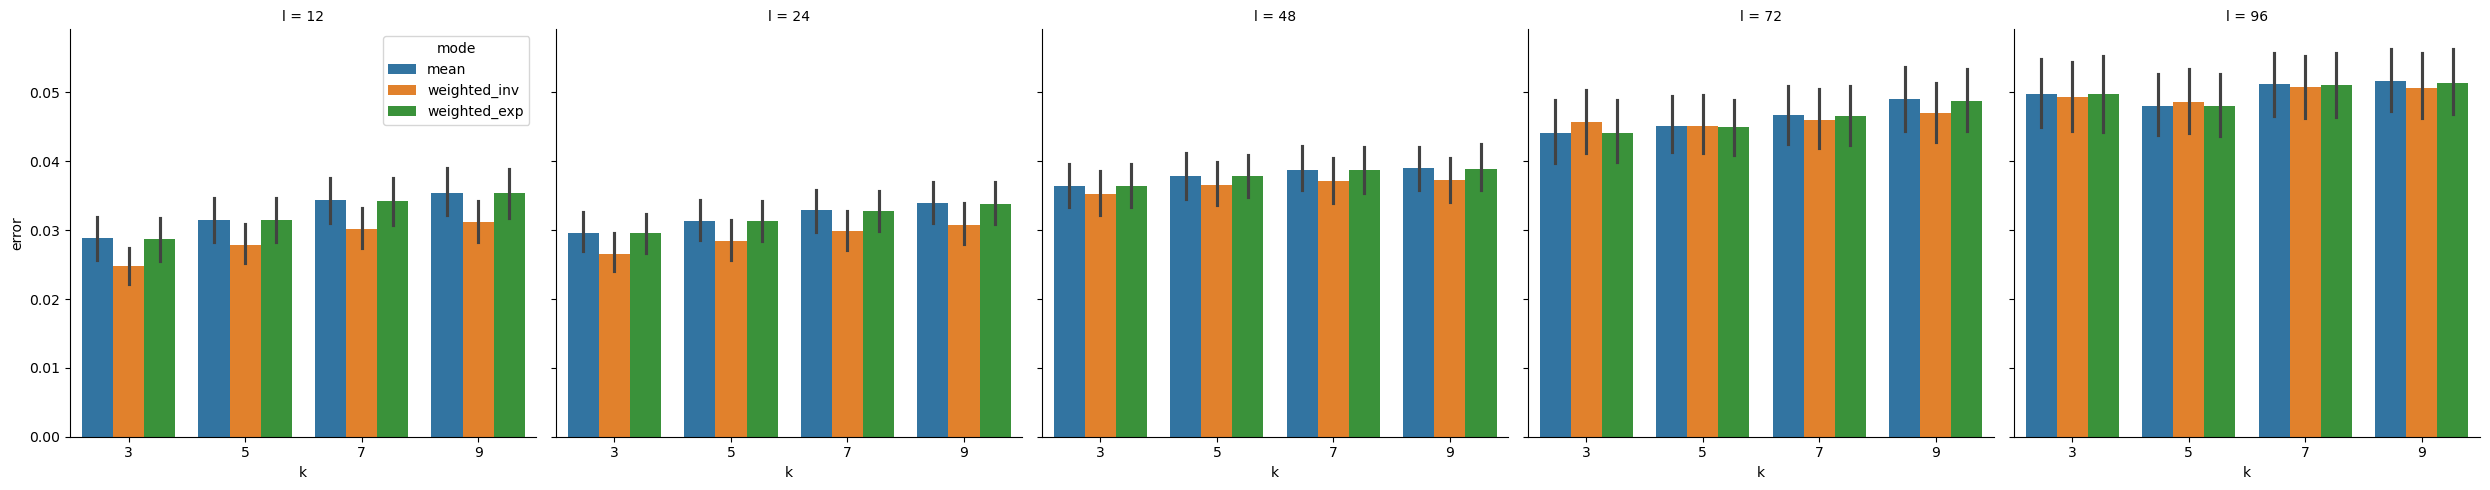

In [66]:
# plot the error for each mode as a function of k and l
sns.catplot(
    data=df,
    x="k",
    y="error",
    hue="mode",
    col="l",
    kind="bar",
    legend_out=False,
)
plt.savefig('figures/error_by_k_l_mode.png')
plt.show()
